In [47]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from torch.nn import BCELoss
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


In [36]:
# yor = np.logical_or(X[:, 0], X[:, 1]).reshape(-1, 1).astype(int)
# yxor = np.logical_xor(X[:, 0], X[:, 1]).reshape(-1, 1).astype(int)
#
# X_train, X_test, yor_train, yor_test, yxor_train, yxor_test = train_test_split(X, yor, yxor, test_size=0.2, random_state=42)

X_train = np.random.uniform(size=(1000,2))
yor_train = np.logical_or(np.round(X_train[:, 0]), np.round(X_train[:, 1])).astype(int).reshape(-1, 1)
yxor_train = np.logical_xor(np.round(X_train[:, 0]), np.round(X_train[:, 1])).astype(int).reshape(-1, 1)
# np.concatenate([X_train, yor.reshape(-1, 1), yxor.reshape(-1, 1)], axis=1)  # for debug

values = np.linspace(0.0, 1.0, 11)
xx, yy = np.meshgrid(values, values)
grid = np.stack([xx, yy], axis=-1)
X_test = grid.reshape(-1, 2)
yor_test = np.logical_or(np.round(X_test[:, 0]), np.round(X_test[:, 1])).astype(int).reshape(-1, 1)
yxor_test = np.logical_xor(np.round(X_test[:, 0]), np.round(X_test[:, 1])).astype(int).reshape(-1, 1)

X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()
yor_train = torch.from_numpy(yor_train).float()
yxor_train = torch.from_numpy(yxor_train).float()

trainOR_dataset = TensorDataset(X_train, yor_train)
trainXOR_dataset = TensorDataset(X_train, yxor_train)

trainOR_loader = DataLoader(trainOR_dataset, batch_size=16)
trainXOR_loader = DataLoader(trainXOR_dataset, batch_size=16)

In [37]:
loss_fn = BCELoss()

In [38]:
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        y = self.sigmoid(x)
        return y


In [39]:
def train_one_epoch(model, epoch_index, optimizer, data_loader):
    running_loss = 0.
    last_loss = 0.

    for i, (inputs, labels) in enumerate(data_loader):
        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        if i % 10 == 0:
            last_loss = running_loss / 1000 # loss per batch
            print(f"  epoch {epoch_index} batch {i+1} loss: {last_loss}")
            running_loss = 0.

    return last_loss

In [40]:
def train_new_model(data_loader, epochs):
    model = Perceptron()

    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

    best_vloss = 1_000_000.

    model.train(True)

    for epoch in range(epochs):
        # Make sure gradient tracking is on, and do a pass over the data
        model.train(True)
        avg_loss = train_one_epoch(model, epoch, optimizer, data_loader)
        print(avg_loss)

    model.eval()

    return model


In [41]:
modelOR = train_new_model(trainOR_loader, 10)

  epoch 0 batch 1 loss: 0.0007610852122306824
  epoch 0 batch 11 loss: 0.006663689315319061
  epoch 0 batch 21 loss: 0.005557972878217697
  epoch 0 batch 31 loss: 0.004096830755472183
  epoch 0 batch 41 loss: 0.00446746951341629
  epoch 0 batch 51 loss: 0.004700165122747422
  epoch 0 batch 61 loss: 0.0037898586094379425
0.0037898586094379425
  epoch 1 batch 1 loss: 0.00039672237634658813
  epoch 1 batch 11 loss: 0.004031455814838409
  epoch 1 batch 21 loss: 0.003863248825073242
  epoch 1 batch 31 loss: 0.003098069578409195
  epoch 1 batch 41 loss: 0.003231963887810707
  epoch 1 batch 51 loss: 0.003645768254995346
  epoch 1 batch 61 loss: 0.00290205579996109
0.00290205579996109
  epoch 2 batch 1 loss: 0.00031067028641700744
  epoch 2 batch 11 loss: 0.0032701431810855867
  epoch 2 batch 21 loss: 0.003244598299264908
  epoch 2 batch 31 loss: 0.0026399694681167605
  epoch 2 batch 41 loss: 0.0027174037247896196
  epoch 2 batch 51 loss: 0.003185051515698433
  epoch 2 batch 61 loss: 0.0025205

0.9008264462809917


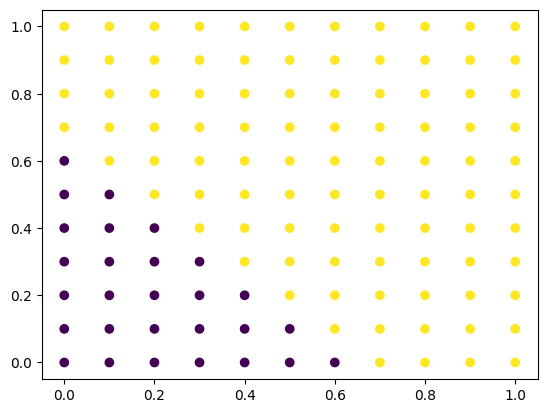

In [50]:
y_pred = modelOR(X_test)
y_pred = np.round(y_pred.detach().numpy())
print(accuracy_score(yor_test, y_pred))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)

In [51]:
modelXOR = train_new_model(trainXOR_loader, 300)

  epoch 0 batch 1 loss: 0.0007029762268066406
  epoch 0 batch 11 loss: 0.006972361743450165
  epoch 0 batch 21 loss: 0.0070157222747802735
  epoch 0 batch 31 loss: 0.007043409049510956
  epoch 0 batch 41 loss: 0.006934386014938354
  epoch 0 batch 51 loss: 0.006986034572124481
  epoch 0 batch 61 loss: 0.007000359535217285
0.007000359535217285
  epoch 1 batch 1 loss: 0.0006830320358276367
  epoch 1 batch 11 loss: 0.006978748142719269
  epoch 1 batch 21 loss: 0.007018639862537384
  epoch 1 batch 31 loss: 0.007001881182193756
  epoch 1 batch 41 loss: 0.006973688900470734
  epoch 1 batch 51 loss: 0.006981939017772674
  epoch 1 batch 61 loss: 0.007000394940376282
0.007000394940376282
  epoch 2 batch 1 loss: 0.0006842056512832642
  epoch 2 batch 11 loss: 0.0069884308576583865
  epoch 2 batch 21 loss: 0.007019906163215637
  epoch 2 batch 31 loss: 0.007001325011253357
  epoch 2 batch 41 loss: 0.006975905358791351
  epoch 2 batch 51 loss: 0.006981657981872559
  epoch 2 batch 61 loss: 0.007001101

0.5041322314049587


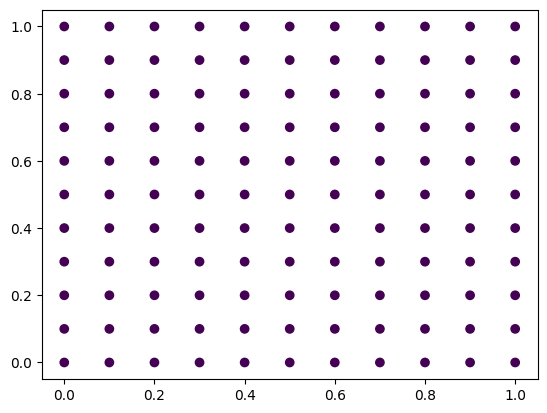

In [52]:
y_pred = modelXOR(X_test)
y_pred = np.round(y_pred.detach().numpy())
print(accuracy_score(yxor_test, y_pred))

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)